In [1]:
!pip install gradio

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import gradio as gr
from wordcloud import WordCloud
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
url = "https://raw.githubusercontent.com/Zurinlakdawala91/Career-Recommendation-System-using-ML/refs/heads/main/stud.csv"
data = pd.read_csv(url)
data.head()

,Drawing,Dancing,Singing,Sports,Video Game,Acting,Travelling,Gardening,Animals,Photography,...,Engeeniering,Doctor,Pharmisist,Cycling,Knitting,Director,Journalism,Bussiness,Listening Music,Courses
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,BBA- Bachelor of Business Administration
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,BBA- Bachelor of Business Administration
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,BBA- Bachelor of Business Administration
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,BBA- Bachelor of Business Administration
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,1,0,BBA- Bachelor of Business Administration


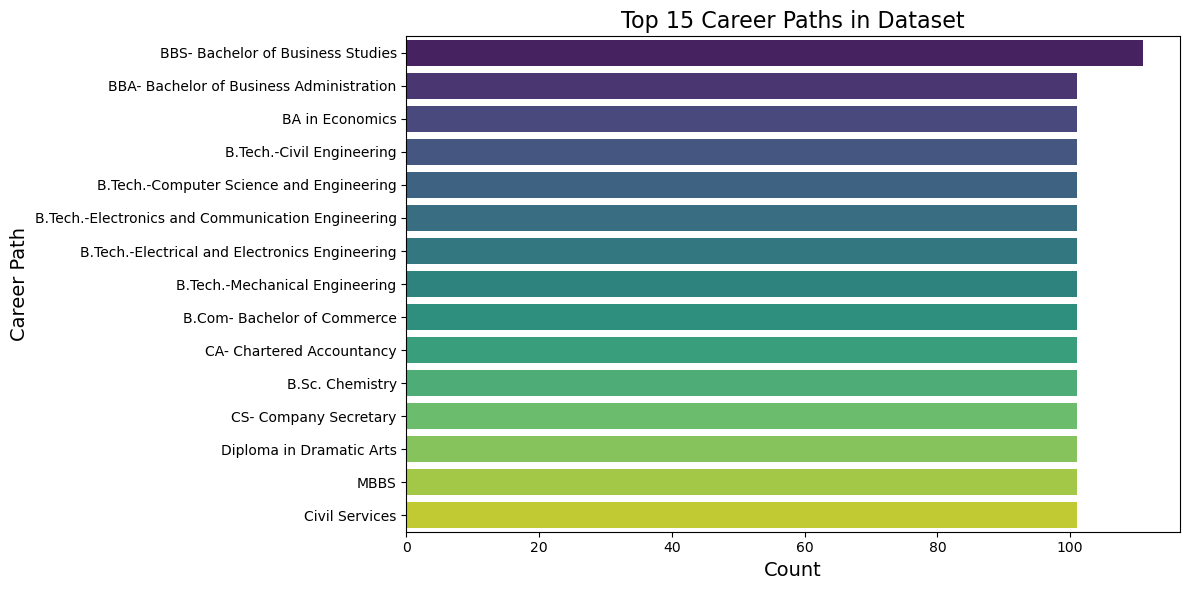

In [5]:
# Visualization Distribution of Top Career Paths
plt.figure(figsize=(12, 6))
career_counts = data['Courses'].value_counts().head(15)
ax = sns.barplot(x=career_counts.values, y=career_counts.index, palette='viridis')
plt.title('Top 15 Career Paths in Dataset', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Career Path', fontsize=14)
plt.tight_layout()
plt.show()
plt.close()


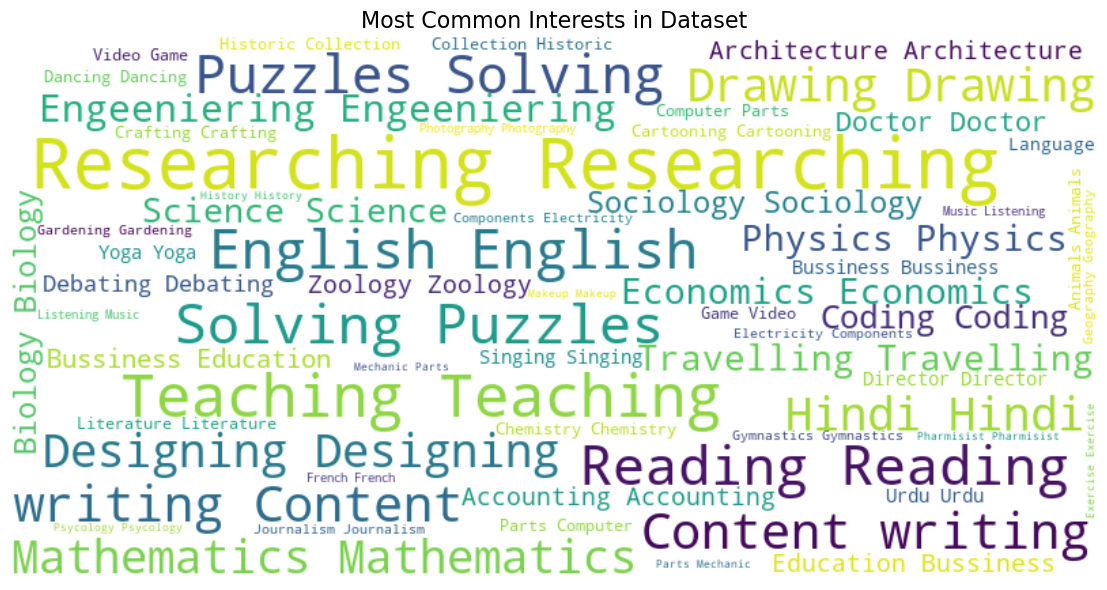

In [7]:
# Visualization Word Cloud of Most Common Interests
all_interests = []
for col in data.columns[:-1]:  # Exclude the 'Courses' column
    if data[col].sum() > 100:  # Only include popular interests
        all_interests.extend([col] * data[col].sum())

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(' '.join(all_interests))
plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Interests in Dataset', fontsize=16)
plt.tight_layout()
plt.show()
plt.close()

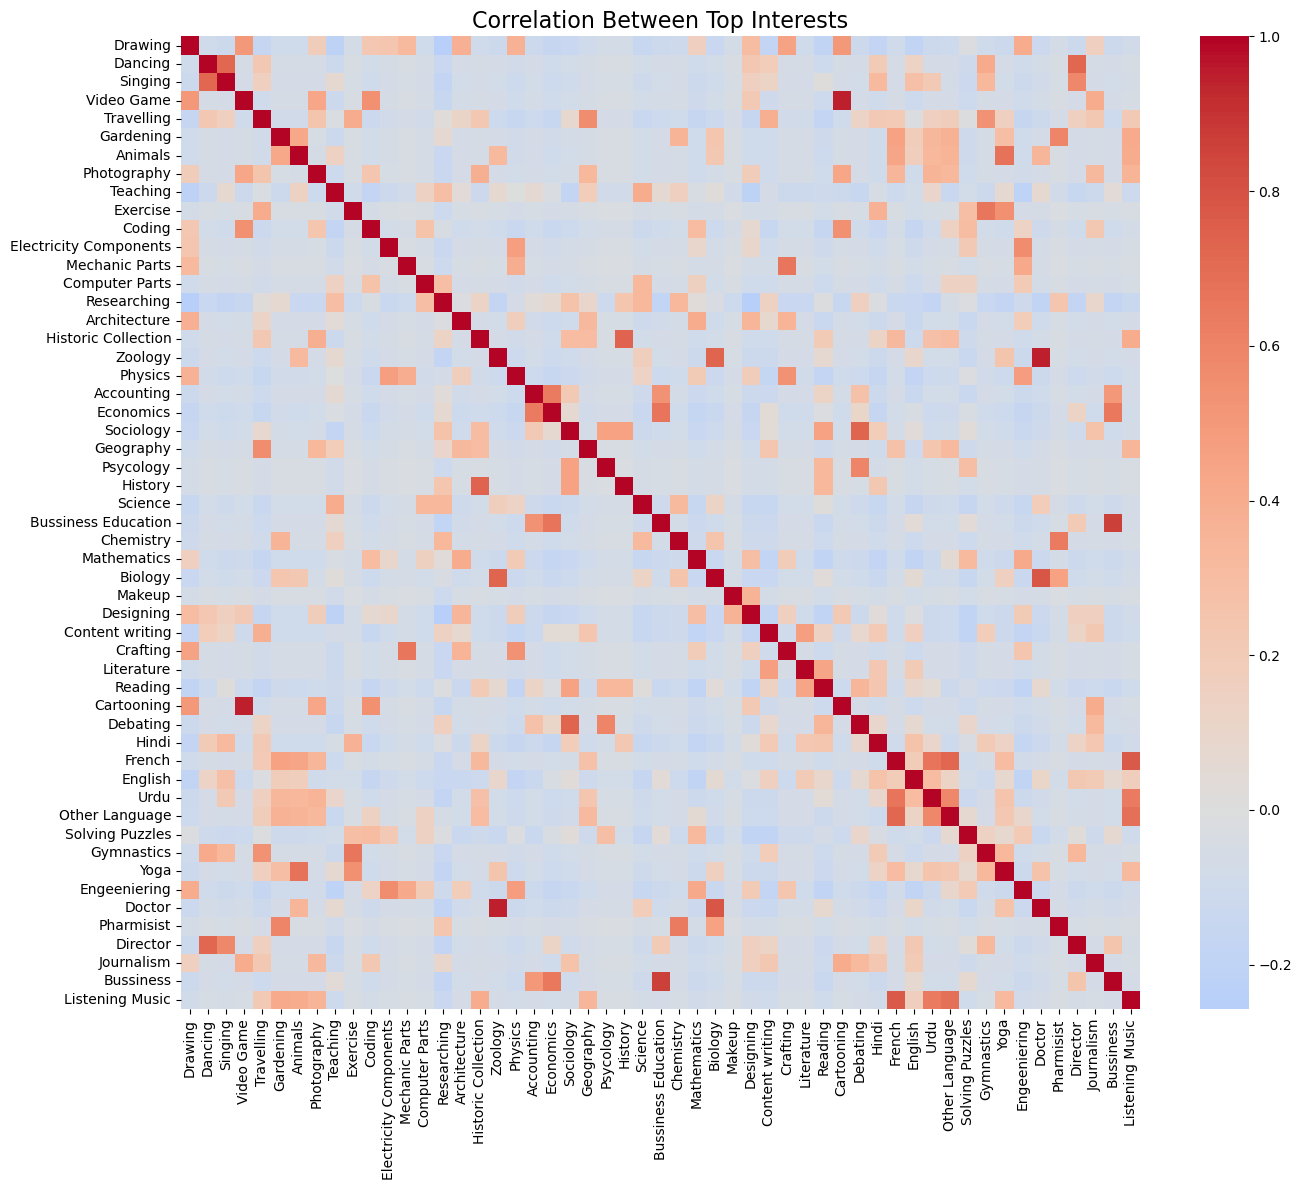

In [9]:
# Visualization Correlation Heatmap of Top Interests
top_interests = [col for col in data.columns[:-1] if data[col].sum() > 100]
plt.figure(figsize=(14, 12))
corr = data[top_interests].corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Between Top Interests', fontsize=16)
plt.tight_layout()
plt.show()
plt.close()

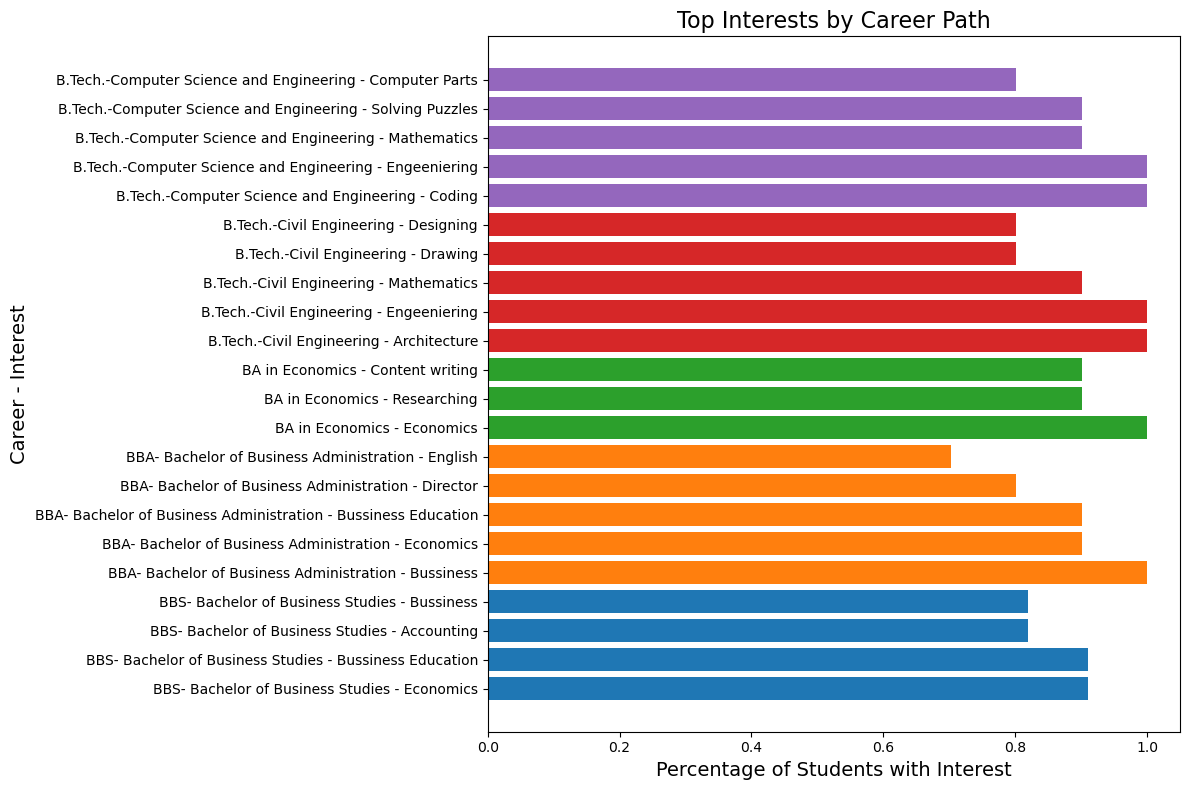

In [11]:
# Visualization Distribution of Interests by Career (Top 5 Careers)
top_5_careers = data['Courses'].value_counts().head(5).index
career_interests = {}
for career in top_5_careers:
    career_data = data[data['Courses'] == career]
    interests = []
    for col in career_data.columns[:-1]:
        if career_data[col].sum() > 0:
            interests.extend([col] * career_data[col].sum())
    most_common = Counter(interests).most_common(5)
    career_interests[career] = [item[0] for item in most_common]

plt.figure(figsize=(12, 8))
for i, (career, interests) in enumerate(career_interests.items()):
    plt.barh([f"{career} - {interest}" for interest in interests],
             [data[interest][data['Courses'] == career].mean() for interest in interests],
             label=career)
plt.title('Top Interests by Career Path', fontsize=16)
plt.xlabel('Percentage of Students with Interest', fontsize=14)
plt.ylabel('Career - Interest', fontsize=14)
plt.tight_layout()
plt.show()
plt.close()

In [13]:
# Model Training
from tensorflow.keras.utils import to_categorical

# Encode the target variable (Courses)
label_encoder = LabelEncoder()
data['Courses_encoded'] = label_encoder.fit_transform(data['Courses'])

# Prepare features and target
X = data.drop(['Courses', 'Courses_encoded'], axis=1)
y = data['Courses_encoded']

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Reshape data for LSTM (samples, timesteps, features)
X_train = np.array(X_train).reshape(X_train.shape[0], 1, X_train.shape[1])
X_test = np.array(X_test).reshape(X_test.shape[0], 1, X_test.shape[1])

# Convert y to categorical (one-hot encoding)
num_classes = len(label_encoder.classes_)
y_train = to_categorical(y_train, num_classes=num_classes)
y_test = to_categorical(y_test, num_classes=num_classes)

print("Model is trained")

Model is trained


In [15]:
# Build LSTM model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential()
model.add(LSTM(128, input_shape=(1, X_train.shape[2]), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(64))
model.add(Dropout(0.2))
model.add(Dense(num_classes, activation='softmax'))

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=50, batch_size=32,
                    validation_data=(X_test, y_test), verbose=1)

Epoch 1/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.3865 - loss: 3.4996 - val_accuracy: 0.7242 - val_loss: 2.8741
Epoch 2/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7649 - loss: 2.0803 - val_accuracy: 0.9406 - val_loss: 0.4724
Epoch 3/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9532 - loss: 0.4005 - val_accuracy: 0.9958 - val_loss: 0.1681
Epoch 4/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9875 - loss: 0.1663 - val_accuracy: 0.9958 - val_loss: 0.0849
Epoch 5/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9978 - loss: 0.0919 - val_accuracy: 0.9958 - val_loss: 0.0511
Epoch 6/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9977 - loss: 0.0654 - val_accuracy: 0.9958 - val_loss: 0.0380
Epoch 7/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9980 - loss: 0.0437 - val_accuracy: 0.9958 - val_loss: 0.0313
Epoch 8/50
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9977 - loss: 0.0353 - val_accuracy: 0.9958 - val_loss

In [17]:
# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Model Accuracy: {accuracy:.2f}")

Model Accuracy: 1.00


In [19]:
## Gradio Interface

# Create a list of all features (interests/skills)
features = X.columns.tolist()

# Create example inputs
example1 = [1 if feat in ['Mathematics', 'Science', 'Physics', 'Chemistry'] else 0 for feat in features]
example2 = [1 if feat in ['Designing', 'Photography', 'Content writing', 'Literature'] else 0 for feat in features]
example3 = [1 if feat in ['Coding', 'Computer Parts', 'Video Game', 'Solving Puzzles'] else 0 for feat in features]

examples = [
    ["Science-oriented student"] + example1,
    ["Creative arts student"] + example2,
    ["Tech-oriented student"] + example3
]

# Modified prediction function for LSTM model
def recommend_career(*interest_values):
    # Create a dictionary from the input values
    input_dict = {feature: int(value) for feature, value in zip(features, interest_values)}

    # Convert to DataFrame then to numpy array with correct shape
    input_df = pd.DataFrame([input_dict])
    input_array = np.array(input_df).reshape(1, 1, len(features))  # Reshape for LSTM

    # Make prediction
    probabilities = model.predict(input_array, verbose=0)[0]
    prediction_encoded = np.argmax(probabilities)
    prediction = label_encoder.inverse_transform([prediction_encoded])[0]

    # Get top 5 predictions
    top_5_indices = np.argsort(probabilities)[-5:][::-1]
    top_5_careers = label_encoder.inverse_transform(top_5_indices)
    top_5_probs = [f"{prob:.2%}" for prob in probabilities[top_5_indices]]

    # Prepare output
    top_recommendation = f" Top Recommendation: {prediction}"

    alternatives_df = pd.DataFrame({
        'Career': top_5_careers,
        'Confidence': top_5_probs
    })

    return top_recommendation, alternatives_df

# Create simplified Gradio interface
with gr.Blocks(title="FutureFit Career Guidance System", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    #  FutureFit Career Guidance System
    *Select your interests and skills to get personalized career recommendations*
    """)

    with gr.Row():
        with gr.Column():
            # Organize checkboxes into categories
            with gr.Tab("Creative Arts"):
                creative_arts = [feat for feat in features if feat in [
                    'Drawing', 'Dancing', 'Singing', 'Acting', 'Photography',
                    'Makeup', 'Designing', 'Content writing', 'Crafting',
                    'Literature', 'Reading', 'Cartooning'
                ]]
                for feat in creative_arts:
                    gr.Checkbox(label=feat, interactive=True)

            with gr.Tab("Technical Skills"):
                technical = [feat for feat in features if feat in [
                    'Coding', 'Electricity Components', 'Mechanic Parts',
                    'Computer Parts', 'Researching', 'Architecture',
                    'Solving Puzzles', 'Engeeniering'
                ]]
                for feat in technical:
                    gr.Checkbox(label=feat, interactive=True)

            with gr.Tab("Academic Interests"):
                academic = [feat for feat in features if feat in [
                    'Mathematics', 'Physics', 'Accounting', 'Economics',
                    'Sociology', 'Geography', 'Psycology', 'History',
                    'Science', 'Chemistry', 'Biology'
                ]]
                for feat in academic:
                    gr.Checkbox(label=feat, interactive=True)

            with gr.Tab("Other Interests"):
                other = [feat for feat in features if feat not in creative_arts + technical + academic]
                for feat in other:
                    gr.Checkbox(label=feat, interactive=True)

    submit_btn = gr.Button("Get Career Recommendations", variant="primary")

    with gr.Row():
        with gr.Column():
            top_recommendation = gr.Markdown(label="Your Career Recommendation")
        with gr.Column():
            alternatives = gr.Dataframe(
                headers=["Career", "Confidence"],
                datatype=["str", "str"],
                interactive=False,
                label="Alternative Options"
            )

    # Set up button click
    submit_btn.click(
        fn=recommend_career,
        inputs=[comp for comp in demo.blocks.values() if isinstance(comp, gr.Checkbox)],
        outputs=[top_recommendation, alternatives]
    )

# Launch the interface
demo.launch(debug=True)

* Running on local URL:  http://127.0.0.1:7861

To create a public link, set `share=True` in `launch()`.


Keyboard interruption in main thread... closing server.


Different model comparisons (KNN,Decision Tree with LSTM)


Decision Tree Results:
Accuracy: 0.80
                                                     precision    recall  f1-score   support

                 Animation, Graphics and Multimedia       1.00      1.00      1.00        18
                   B.Arch- Bachelor of Architecture       1.00      1.00      1.00        19
                        B.Com- Bachelor of Commerce       1.00      0.76      0.86        21
                                              B.Ed.       1.00      0.74      0.85        23
                              B.Sc- Applied Geology       0.12      1.00      0.21        18
                                      B.Sc- Nursing       1.00      1.00      1.00        19
                                    B.Sc. Chemistry       1.00      1.00      1.00        25
                                  B.Sc. Mathematics       1.00      1.00      1.00        23
                      B.Sc.- Information Technology       1.00      1.00      1.00        20
                              

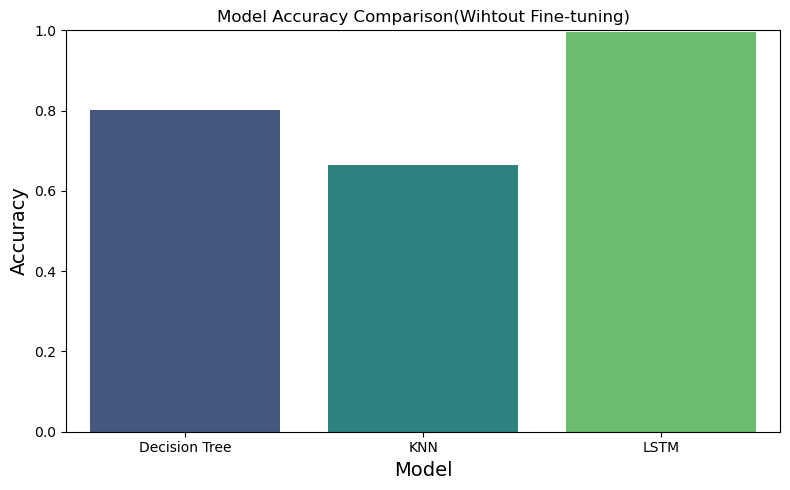

In [43]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import numpy as np

# Preprocessing
label_encoder = LabelEncoder()
data['Courses_encoded'] = label_encoder.fit_transform(data['Courses'])

X = data.drop(['Courses', 'Courses_encoded'], axis=1)
y = data['Courses_encoded']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Decision Tree Model
dt_model = DecisionTreeClassifier(max_depth=20, random_state=42)
dt_model.fit(X_train, y_train)

# Evaluate Decision Tree
dt_y_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_y_pred)
print("\nDecision Tree Results:")
print(f"Accuracy: {dt_accuracy:.2f}")
print(classification_report(y_test, dt_y_pred, target_names=label_encoder.classes_))

# KNN Model
knn_model = KNeighborsClassifier(n_neighbors=250)
knn_model.fit(X_train, y_train)

# Evaluate KNN
knn_y_pred = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_y_pred)
print("\nKNN Results:")
print(f"Accuracy: {knn_accuracy:.2f}")
print(classification_report(y_test, knn_y_pred, target_names=label_encoder.classes_))

# LSTM Model
X_train_lstm = np.array(X_train).reshape(X_train.shape[0], 1, X_train.shape[1])
X_test_lstm = np.array(X_test).reshape(X_test.shape[0], 1, X_test.shape[1])

num_classes = len(label_encoder.classes_)
y_train_lstm = to_categorical(y_train, num_classes=num_classes)
y_test_lstm = to_categorical(y_test, num_classes=num_classes)

lstm_model = Sequential()
lstm_model.add(LSTM(128, input_shape=(1, X_train_lstm.shape[2]), return_sequences=True))
lstm_model.add(Dropout(0.2))
lstm_model.add(LSTM(64))
lstm_model.add(Dropout(0.2))
lstm_model.add(Dense(num_classes, activation='softmax'))

lstm_model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

print("\nTraining LSTM model...")
history = lstm_model.fit(X_train_lstm, y_train_lstm, epochs=50, batch_size=32,
                        validation_data=(X_test_lstm, y_test_lstm), verbose=1)

lstm_loss, lstm_accuracy = lstm_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
print("\nLSTM Results:")
print(f"Accuracy: {lstm_accuracy:.2f}")

# Model Comparison
print("\nModel Comparison:")
print(f"Decision Tree Accuracy: {dt_accuracy:.2f}")
print(f"KNN Accuracy: {knn_accuracy:.2f}")
print(f"LSTM Accuracy: {lstm_accuracy:.2f}")

# Visualization
plt.figure(figsize=(8, 5))
models = ['Decision Tree', 'KNN', 'LSTM']
accuracies = [dt_accuracy, knn_accuracy, lstm_accuracy]
sns.barplot(x=models, y=accuracies, palette='viridis')
plt.title(f'Model Accuracy Comparison(Wihtout Fine-tuning)')
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
plt.close()

In [23]:
from sklearn.model_selection import GridSearchCV
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Fine Tuning
# Fine-Tuned Decision Tree 
dt_param_grid = {
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), dt_param_grid, cv=5, n_jobs=-1)
dt_grid.fit(X_train, y_train)

dt_best_model = dt_grid.best_estimator_
dt_y_pred_best = dt_best_model.predict(X_test)
dt_accuracy_best = accuracy_score(y_test, dt_y_pred_best)
print("\nFine-Tuned Decision Tree Results:")
print(f"Accuracy: {dt_accuracy_best:.2f}")
print(classification_report(y_test, dt_y_pred_best, target_names=label_encoder.classes_))

# Fine-Tuned KNN 
knn_param_grid = {
    'n_neighbors': [3, 5, 10, 20, 50]
}
knn_grid = GridSearchCV(KNeighborsClassifier(), knn_param_grid, cv=5, n_jobs=-1)
knn_grid.fit(X_train, y_train)

knn_best_model = knn_grid.best_estimator_
knn_y_pred_best = knn_best_model.predict(X_test)
knn_accuracy_best = accuracy_score(y_test, knn_y_pred_best)
print("\nFine-Tuned KNN Results:")
print(f"Accuracy: {knn_accuracy_best:.2f}")
print(classification_report(y_test, knn_y_pred_best, target_names=label_encoder.classes_))

# Fine-Tuned LSTM 
# Data already reshaped: X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm

lstm_tuned_model = Sequential()
lstm_tuned_model.add(LSTM(256, input_shape=(1, X_train_lstm.shape[2]), return_sequences=True))
lstm_tuned_model.add(Dropout(0.3))
lstm_tuned_model.add(LSTM(128))
lstm_tuned_model.add(Dropout(0.3))
lstm_tuned_model.add(Dense(num_classes, activation='softmax'))

lstm_tuned_model.compile(
    loss='categorical_crossentropy', 
    optimizer='adam', 
    metrics=['accuracy']
)

early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3)

print("\nTraining Fine-Tuned LSTM model...")
history_tuned = lstm_tuned_model.fit(
    X_train_lstm, y_train_lstm,
    epochs=100,
    batch_size=16,  # smaller batch size
    validation_data=(X_test_lstm, y_test_lstm),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

lstm_loss_best, lstm_accuracy_best = lstm_tuned_model.evaluate(X_test_lstm, y_test_lstm, verbose=0)
print("\nFine-Tuned LSTM Results:")
print(f"Accuracy: {lstm_accuracy_best:.2f}")

# Model Comparison (Fine-Tuned vs Without)
print("\nModel Comparison (Before and After Fine-Tuning):")
print(f"Decision Tree - Before: {dt_accuracy:.2f}, After: {dt_accuracy_best:.2f}")
print(f"KNN - Before: {knn_accuracy:.2f}, After: {knn_accuracy_best:.2f}")
print(f"LSTM - Before: {lstm_accuracy:.2f}, After: {lstm_accuracy_best:.2f}")



Fine-Tuned Decision Tree Results:
Accuracy: 1.00
                                                     precision    recall  f1-score   support

                 Animation, Graphics and Multimedia       1.00      1.00      1.00        18
                   B.Arch- Bachelor of Architecture       1.00      1.00      1.00        19
                        B.Com- Bachelor of Commerce       1.00      0.86      0.92        21
                                              B.Ed.       1.00      1.00      1.00        23
                              B.Sc- Applied Geology       1.00      1.00      1.00        18
                                      B.Sc- Nursing       1.00      1.00      1.00        19
                                    B.Sc. Chemistry       1.00      1.00      1.00        25
                                  B.Sc. Mathematics       1.00      1.00      1.00        23
                      B.Sc.- Information Technology       1.00      1.00      1.00        20
                   

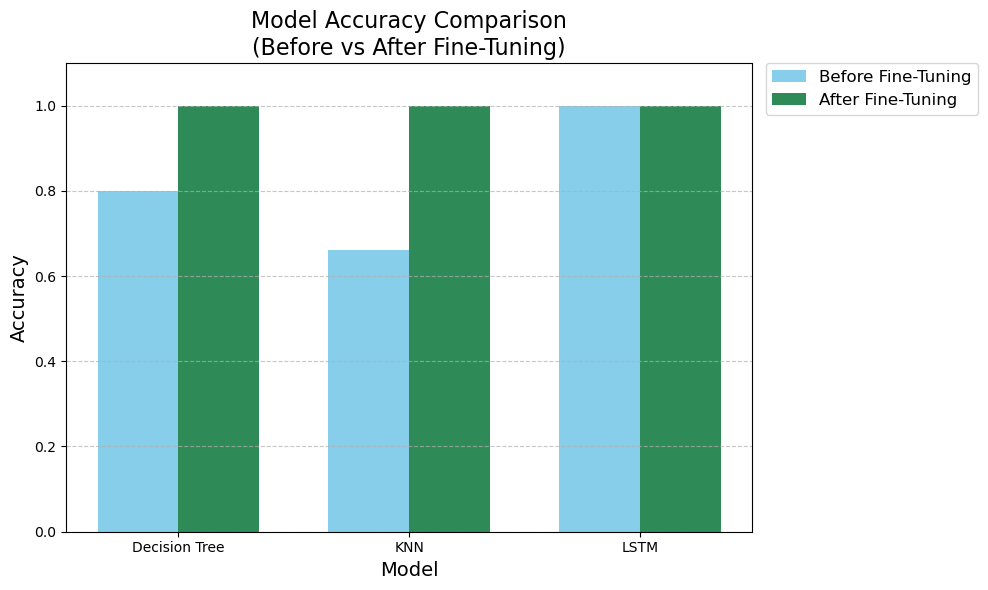

In [53]:
import matplotlib.pyplot as plt
import numpy as np

models = ['Decision Tree', 'KNN', 'LSTM']
before = [0.80, 0.66, 1.00]
after = [1.00, 1.00, 1.00]

x = np.arange(len(models))  #label locations
width = 0.35  #width of bars

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, before, width, label='Before Fine-Tuning', color='skyblue')
bars2 = ax.bar(x + width/2, after, width, label='After Fine-Tuning', color='seagreen')

ax.set_xlabel('Model', fontsize=14)
ax.set_ylabel('Accuracy', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.1)
ax.grid(axis='y', linestyle='--', alpha=0.7)

# Move legend to the top-right corner outside the plot
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0, fontsize=12)

# Title remains centered
plt.title('Model Accuracy Comparison\n(Before vs After Fine-Tuning)', fontsize=16)

plt.tight_layout()
plt.show()


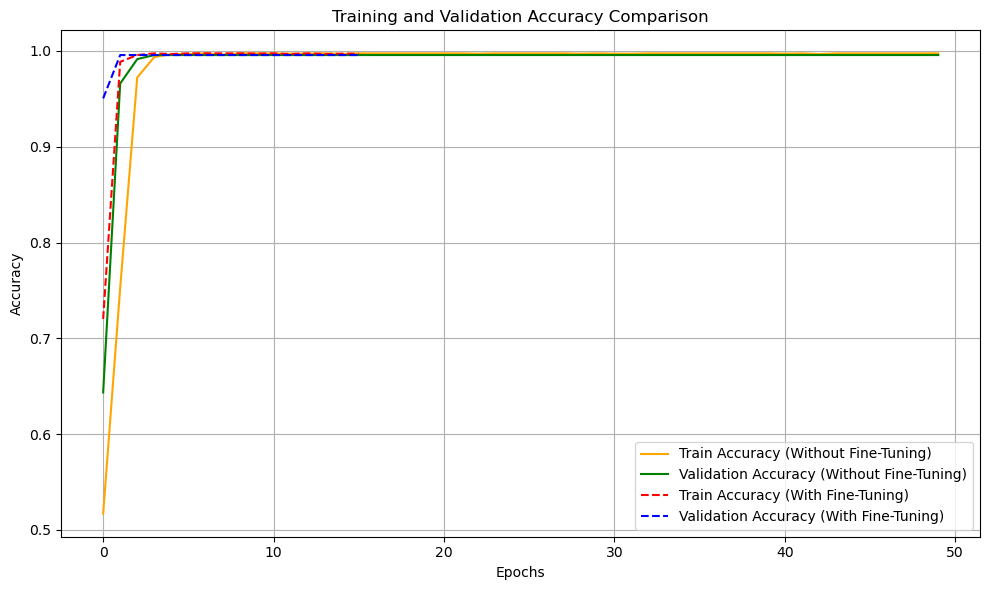

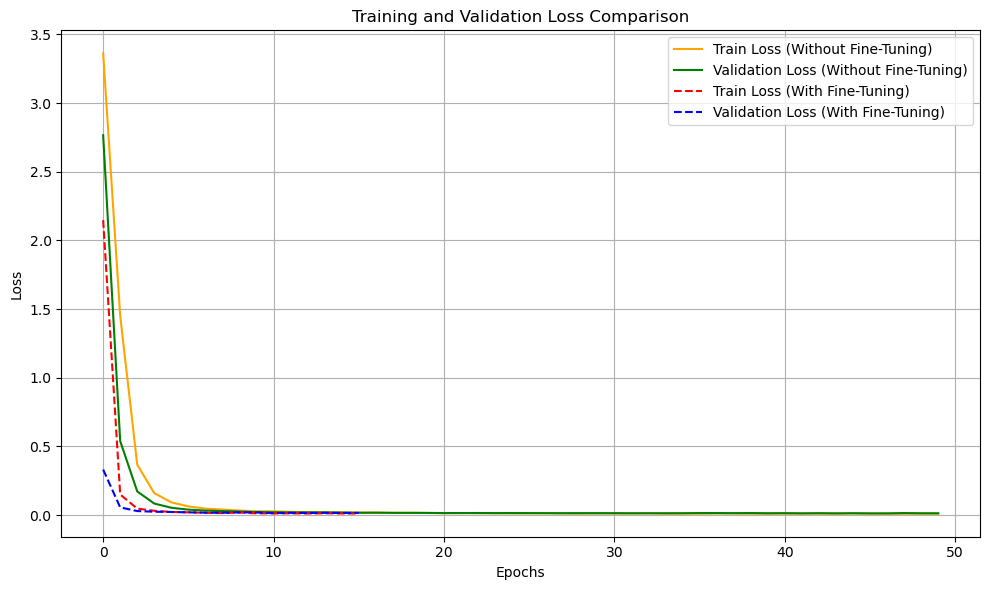

In [51]:
import matplotlib.pyplot as plt

# Plot and Save Training and Validation Accuracy
plt.figure(figsize=(10,6))
plt.plot(history.history['accuracy'], color='orange', label='Train Accuracy (Without Fine-Tuning)')
plt.plot(history.history['val_accuracy'], color='green', label='Validation Accuracy (Without Fine-Tuning)')
plt.plot(history_tuned.history['accuracy'], color='red', linestyle='--', label='Train Accuracy (With Fine-Tuning)')
plt.plot(history_tuned.history['val_accuracy'], color='blue', linestyle='--', label='Validation Accuracy (With Fine-Tuning)')
plt.title('Training and Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('training_validation_accuracy.png') 
plt.show()

# Plot and Save Training and Validation Loss
plt.figure(figsize=(10,6))
plt.plot(history.history['loss'], color='orange', label='Train Loss (Without Fine-Tuning)')
plt.plot(history.history['val_loss'], color='green', label='Validation Loss (Without Fine-Tuning)')
plt.plot(history_tuned.history['loss'], color='red', linestyle='--', label='Train Loss (With Fine-Tuning)')
plt.plot(history_tuned.history['val_loss'], color='blue', linestyle='--', label='Validation Loss (With Fine-Tuning)')
plt.title('Training and Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('training_validation_loss.png') 
plt.show()
